# 02 - Keşifsel Veri Analizi (EDA)

Bu notebook, `01_data_cleaning` sonrasında oluşturulan **işlenmiş veri setleri** üzerinden keşifsel veri analizini (EDA) gerçekleştirir.

- Genel metrikler (sipariş sayısı, müşteri sayısı, toplam gelir vb.)
- Zaman bazlı trend analizi (aylık sipariş & gelir)
- Müşteri & ürün kırılımlarında temel analizler

Analizlerde ana kaynak olarak `data/processed/fact_orders.parquet` kullanılacaktır.

In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Görselleştirme ayarları
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_RAW = "../data/raw"
DATA_PROCESSED = "../data/processed"

fact_orders = pd.read_parquet(os.path.join(DATA_PROCESSED, "fact_orders.parquet"))

# Ödeme yöntemi analizi için raw payments tablosu
order_payments = pd.read_csv(os.path.join(DATA_RAW, "olist_order_payments_dataset.csv"))

fact_orders.head()


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,customer_city,customer_state,payment_value,payment_installments,review_score,review_count,total_item_value,order_date,order_year,order_month
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,campos dos goytacazes,RJ,72.19,2.0,5.0,1.0,72.19,2017-09-13,2017,2017-09
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,santa fe do sul,SP,259.83,3.0,4.0,1.0,259.83,2017-04-26,2017,2017-04
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,para de minas,MG,216.87,5.0,5.0,1.0,216.87,2018-01-14,2018,2018-01
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,atibaia,SP,25.78,2.0,4.0,1.0,25.78,2018-08-08,2018,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,varzea paulista,SP,218.04,3.0,5.0,1.0,218.04,2017-02-04,2017,2017-02


## Veri setine genel bakış

Bu bölümde `fact_orders` veri setinin boyutunu, kolonlarını ve eksik değer durumunu inceleyerek veri yapısını hızlıca anlayacağız.

In [15]:
# Veri seti boyutu ve kolonlar
print("Satır sayısı:", len(fact_orders))
print("Kolon sayısı:", fact_orders.shape[1])

fact_orders.info()

Satır sayısı: 112650
Kolon sayısı: 38
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 38 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  object        
 1   order_item_id                  112650 non-null  int64         
 2   product_id                     112650 non-null  object        
 3   seller_id                      112650 non-null  object        
 4   shipping_limit_date            112650 non-null  object        
 5   price                          112650 non-null  float64       
 6   freight_value                  112650 non-null  float64       
 7   product_category_name          112650 non-null  object        
 8   product_name_lenght            111047 non-null  float64       
 9   product_description_lenght     111047 non-null  float64       
 10  product_photos_qty            

In [16]:
# Eksik değer oranları (ilk 20 kolon)
na_ratio = fact_orders.isna().mean().sort_values(ascending=False)
na_ratio.head(20)

order_delivered_customer_date    0.021784
product_category_name_english    0.014443
product_name_lenght              0.014230
product_description_lenght       0.014230
product_photos_qty               0.014230
order_delivered_carrier_date     0.010599
review_count                     0.008362
review_score                     0.008362
product_weight_g                 0.000160
product_width_cm                 0.000160
product_height_cm                0.000160
product_length_cm                0.000160
order_approved_at                0.000133
payment_installments             0.000027
payment_value                    0.000027
total_item_value                 0.000000
order_date                       0.000000
order_year                       0.000000
customer_state                   0.000000
customer_city                    0.000000
dtype: float64

## Özet metrikler

Bu bölümde temel iş metriklerine bakacağız:

- Toplam sipariş sayısı
- Benzersiz müşteri sayısı
- Analiz edilen tarih aralığı
- Toplam gelir ve ortalama sipariş tutarı
- Sipariş durumu dağılımı (delivered, shipped vb.)

In [17]:
# Toplam sipariş ve müşteri sayısı
n_orders = fact_orders["order_id"].nunique()
n_customers = fact_orders["customer_id"].nunique()

# Tarih aralığı
min_date = fact_orders["order_date"].min()
max_date = fact_orders["order_date"].max()

# Toplam ve ortalama gelir (sipariş kalemi bazında)
total_revenue = fact_orders["total_item_value"].sum()
revenue_per_order = fact_orders.groupby("order_id")["total_item_value"].sum().mean()

print(f"Toplam sipariş sayısı: {n_orders:,}")
print(f"Benzersiz müşteri sayısı: {n_customers:,}")
print(f"Tarih aralığı: {min_date} → {max_date}")
print(f"Toplam gelir (item + freight): {total_revenue:,.2f}")
print(f"Ortalama sipariş tutarı: {revenue_per_order:,.2f}")

Toplam sipariş sayısı: 98,666
Benzersiz müşteri sayısı: 98,666
Tarih aralığı: 2016-09-04 → 2018-09-03
Toplam gelir (item + freight): 15,843,553.24
Ortalama sipariş tutarı: 160.58


In [18]:
# Sipariş durumu dağılımı
status_counts = fact_orders.drop_duplicates("order_id")["order_status"].value_counts(normalize=True) * 100
status_counts

order_status
delivered      97.782417
shipped         1.120954
canceled        0.467233
invoiced        0.316218
processing      0.305070
unavailable     0.006081
approved        0.002027
Name: proportion, dtype: float64

## Zaman bazlı trend analizi

Bu bölümde özellikle **aylık sipariş adedi** ve **aylık gelir** trendlerine odaklanacağız. Analizleri, ürünlerin teslim edilmiş olduğu siparişler (`order_status == "delivered"`) üzerinden yapmak daha sağlıklı sonuç verir.

In [19]:
# Sadece teslim edilmiş siparişler
fact_delivered = fact_orders[fact_orders["order_status"] == "delivered"].copy()

# Aylık sipariş ve gelir metrikleri
monthly_metrics = (
    fact_delivered
    .groupby("order_month")
    .agg(
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
        revenue=("total_item_value", "sum"),
    )
    .sort_index()
)

# İlk ve son ay genelde kırık/eksik olabiliyor; trend için kırpılmış versiyon
monthly_metrics_trimmed = monthly_metrics.iloc[1:-1].copy() if len(monthly_metrics) > 2 else monthly_metrics.copy()

# MoM (Month-over-Month) büyüme oranları
monthly_metrics_trimmed["orders_mom"] = monthly_metrics_trimmed["orders"].pct_change() * 100
monthly_metrics_trimmed["revenue_mom"] = monthly_metrics_trimmed["revenue"].pct_change() * 100

monthly_metrics_trimmed.head()


,orders,customers,revenue,orders_mom,revenue_mom
order_month,,,,,
2016-10,265,262,46490.66,NaN,NaN
2016-12,1,1,19.62,-99.622642,-99.957798
2017-01,750,718,127482.37,74900.000000,649657.237513
2017-02,1653,1630,271239.32,120.400000,112.766142
2017-03,2546,2508,414330.95,54.022989,52.754752


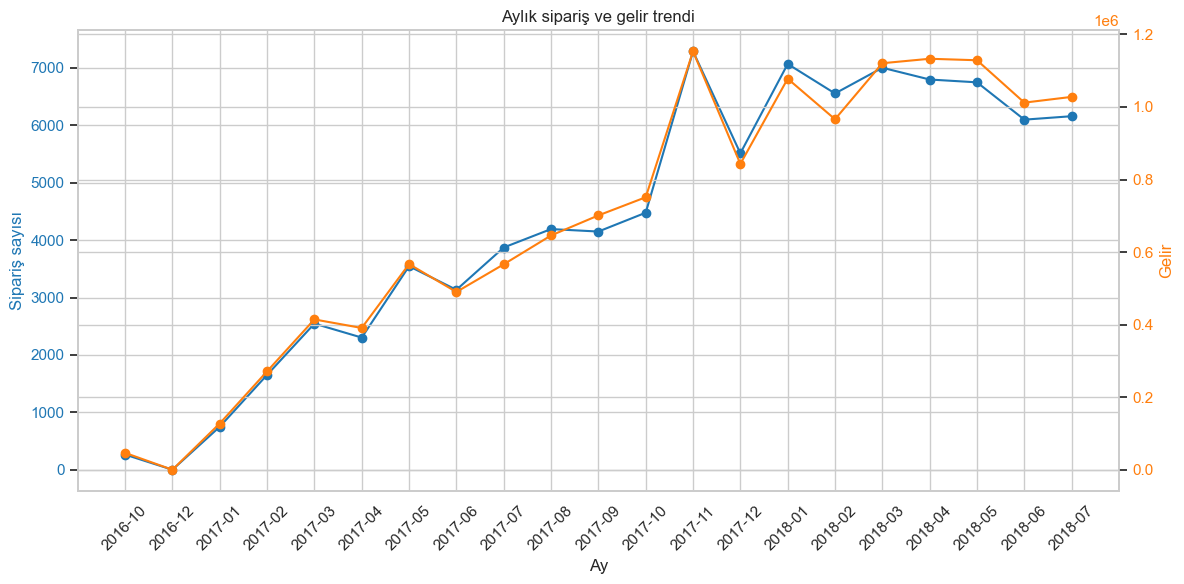

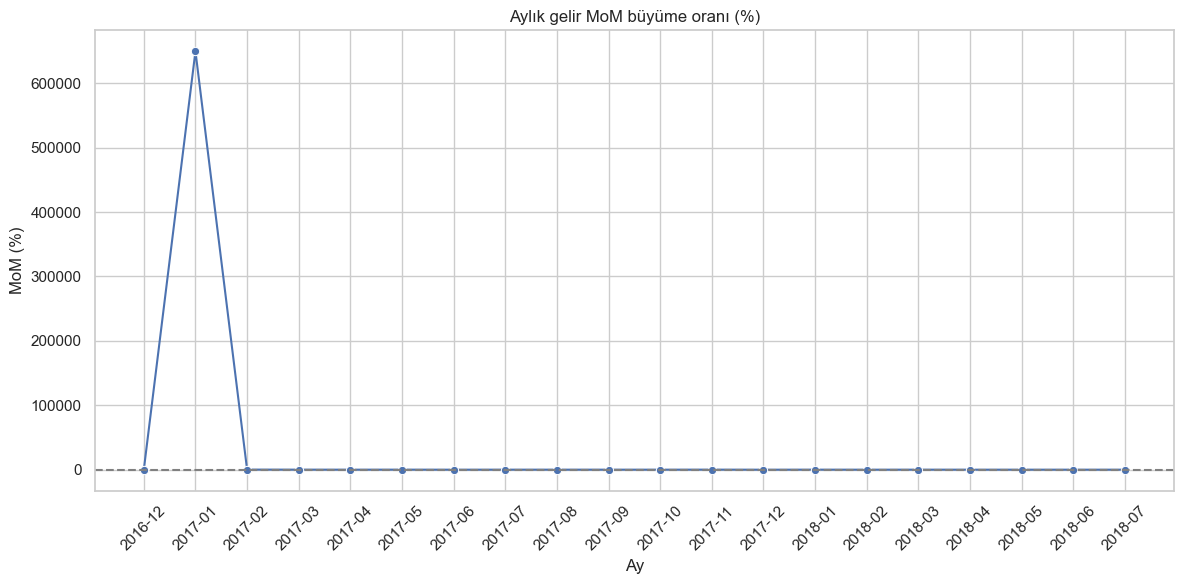

In [20]:
# Aylık sipariş adedi ve gelir trendi (delivered, ilk/son ay kırpılmış)
fig, ax1 = plt.subplots()

ax1.plot(monthly_metrics_trimmed.index, monthly_metrics_trimmed["orders"], color="tab:blue", marker="o")
ax1.set_xlabel("Ay")
ax1.set_ylabel("Sipariş sayısı", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
plt.xticks(rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly_metrics_trimmed.index, monthly_metrics_trimmed["revenue"], color="tab:orange", marker="o")
ax2.set_ylabel("Gelir", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Aylık sipariş ve gelir trendi")
plt.tight_layout()
plt.show()

# MoM büyüme oranı (gelir)
sns.lineplot(
    data=monthly_metrics_trimmed.reset_index(),
    x="order_month",
    y="revenue_mom",
    marker="o",
)
plt.xticks(rotation=45)
plt.axhline(0, color="grey", linestyle="--")
plt.title("Aylık gelir MoM büyüme oranı (%)")
plt.xlabel("Ay")
plt.ylabel("MoM (%)")
plt.tight_layout()
plt.show()


## Kategori bazlı temel analiz

Bu bölümde ürün kategorileri bazında:

- Toplam gelir
- Sipariş adedi
- Satılan ürün adedi
- Ortalama sipariş kalemi değeri

gibi metriklere bakarak hangi kategorilerin öne çıktığını inceleyeceğiz.

In [21]:
# Kategori bazlı metrikler (delivered siparişler)
cat_metrics = (
    fact_delivered
    .groupby("product_category_name_english")
    .agg(
        revenue=("total_item_value", "sum"),
        orders=("order_id", "nunique"),
        items_sold=("order_item_id", "count"),
        avg_item_value=("total_item_value", "mean"),
    )
    .sort_values("revenue", ascending=False)
)

cat_metrics.head(10)

,revenue,orders,items_sold,avg_item_value
product_category_name_english,,,,
health_beauty,1412089.53,8647,9465,149.190653
watches_gifts,1264333.12,5495,5859,215.793330
bed_bath_table,1225209.26,9272,10953,111.860610
sports_leisure,1118256.91,7530,8431,132.636331
computers_accessories,1032723.77,6530,7644,135.102534
furniture_decor,880329.92,6307,8160,107.883569
housewares,758392.25,5743,6795,111.610338
cool_stuff,691680.89,3559,3718,186.035742
auto,669454.75,3810,4140,161.704046


/var/folders/0n/l1l_2y613jb9_l5sgq8gdfm00000gn/T/ipykernel_89833/4117265016.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


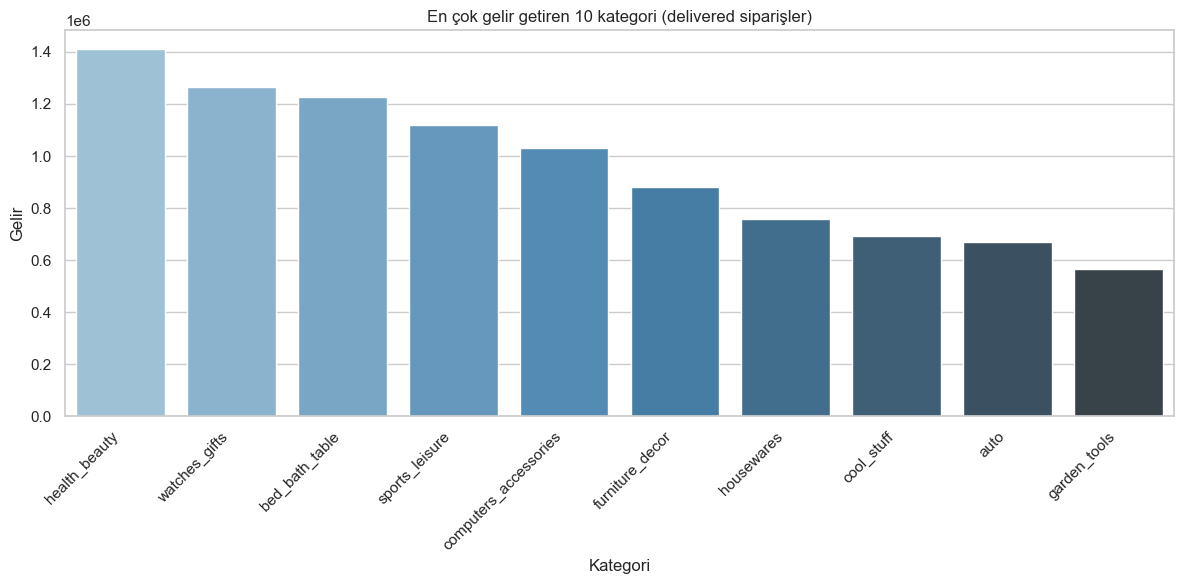

In [22]:
# En çok gelir getiren 10 kategori (bar plot)

plt.figure(figsize=(12, 6))

top_n = 10
sns.barplot(
    data=cat_metrics.head(top_n).reset_index(),
    x="product_category_name_english",
    y="revenue",
    hue="product_category_name_english",
    palette="Blues_d",
    legend=False,
)
plt.xticks(rotation=45, ha="right")
plt.title("En çok gelir getiren 10 kategori (delivered siparişler)")
plt.xlabel("Kategori")
plt.ylabel("Gelir")
plt.tight_layout()
plt.show()

## Sayısal kolonlar dağılım özeti

Fiyat, kargo, ödeme ve gelir gibi sayısal metriklerin temel istatistikleri; aykırı değer / dağılım hakkında hızlı bir resim verir.

In [25]:
numeric_cols = ["price", "freight_value", "total_item_value"]

# payment_value order seviyesinde olduğu için item satırlarında tekrar edebilir.
# Sipariş seviyesinde toplam ödeme değerlerini incelemek için fact_orders.drop_duplicates kullanıyoruz.
order_level_payment = fact_orders.drop_duplicates("order_id")["payment_value"]
order_level_revenue = fact_orders.groupby("order_id")["total_item_value"].sum()

print("Item-level sayısal özet")
display(fact_orders[numeric_cols].describe().T)

print("Order-level ödeme (payment_value) özeti")
display(order_level_payment.describe())

print("Order-level toplam tutar özet")
display(order_level_revenue.describe())


Item-level sayısal özet


,count,mean,std,min,25%,50%,75%,max
price,112650.0,120.653739,183.633928,0.85,39.90,74.99,134.9000,6735.00
freight_value,112650.0,19.990320,15.806405,0.00,13.08,16.26,21.1500,409.68
payment_value,112647.0,180.281186,272.849042,9.59,65.67,114.44,195.3900,13664.08
total_item_value,112650.0,140.644059,190.724394,6.08,55.22,92.32,157.9375,6929.31


Order-level toplam tutar özet


count    98666.000000
mean       160.577638
std        220.466087
min          9.590000
25%         61.980000
50%        105.290000
75%        176.870000
max      13664.080000
Name: total_item_value, dtype: float64

## Müşteri segmentasyonu ve tekrar satın alma

E-ticaret EDA'sının kritik sorularından biri: **kaç müşteri tekrar sipariş veriyor?** Bu bölümde `customer_unique_id` üzerinden tekrar satın alma oranlarını ve basit segmentleri çıkaracağız.

Tekrar sipariş veren müşteri oranı (>=2 sipariş): 3.05%


segment
1      96.947181
2       2.801300
3-5     0.241040
5+      0.010480
Name: proportion, dtype: float64

/var/folders/0n/l1l_2y613jb9_l5sgq8gdfm00000gn/T/ipykernel_89833/2700879358.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg_dist.index.astype(str), y=seg_dist.values, palette="Blues_d")


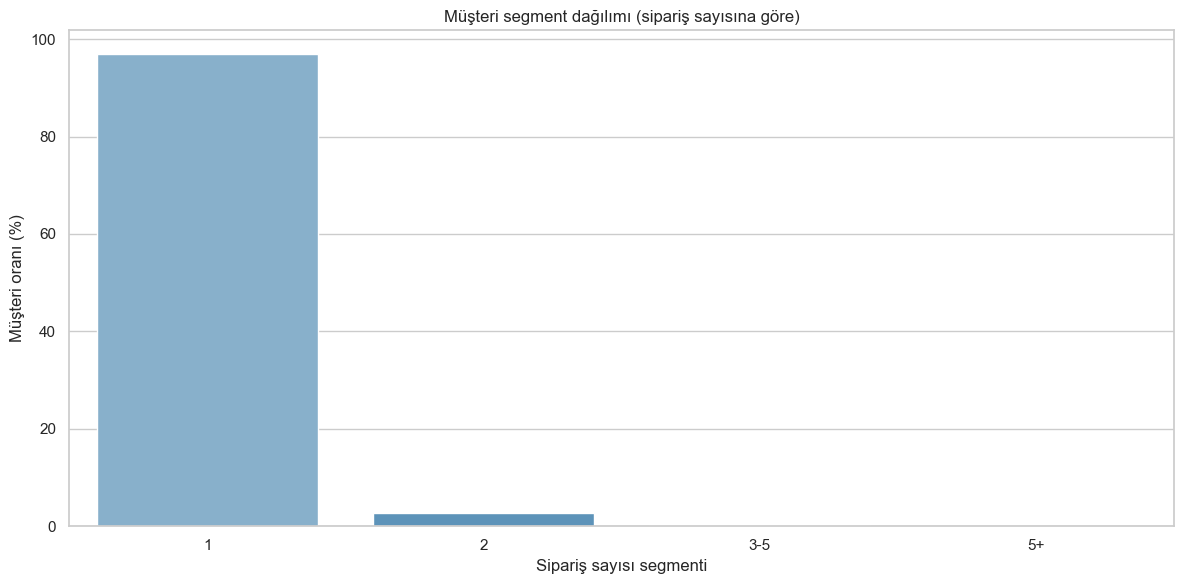

In [26]:
# Müşteri bazında sipariş sayısı (order-level)
orders_unique = fact_orders.drop_duplicates("order_id")[["order_id", "customer_unique_id", "order_status", "order_month"]].copy()

cust_orders = (
    orders_unique
    .groupby("customer_unique_id", as_index=False)
    .agg(order_count=("order_id", "count"))
)

repeat_rate = (cust_orders["order_count"] >= 2).mean() * 100
print(f"Tekrar sipariş veren müşteri oranı (>=2 sipariş): {repeat_rate:.2f}%")

# Segmentleme
cust_orders["segment"] = pd.cut(
    cust_orders["order_count"],
    bins=[0, 1, 2, 5, cust_orders["order_count"].max()],
    labels=["1", "2", "3-5", "5+"],
    include_lowest=True,
)

seg_dist = cust_orders["segment"].value_counts(normalize=True).sort_index() * 100
display(seg_dist)

sns.barplot(x=seg_dist.index.astype(str), y=seg_dist.values, hue=seg_dist.index.astype(str), palette="Blues_d", legend=False)
plt.title("Müşteri segment dağılımı (sipariş sayısına göre)")
plt.xlabel("Sipariş sayısı segmenti")
plt.ylabel("Müşteri oranı (%)")
plt.tight_layout()
plt.show()


## Coğrafi analiz (müşteri ve satıcı)

Bu bölümde `customer_state` ve `seller_state` kırılımlarını inceleyerek hangi eyaletlerin daha fazla sipariş ve gelir ürettiğini görürüz.

,orders,customers,revenue
customer_state,,,
SP,40501,39156,5769703.15
RJ,12350,11917,2055401.57
MG,11354,11001,1818891.67
RS,5345,5168,861472.79
PR,4923,4769,781708.80
SC,3546,3449,595127.78
BA,3256,3158,591137.81
DF,2080,2019,346123.35
ES,1995,1928,317657.93


/var/folders/0n/l1l_2y613jb9_l5sgq8gdfm00000gn/T/ipykernel_89833/699799299.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


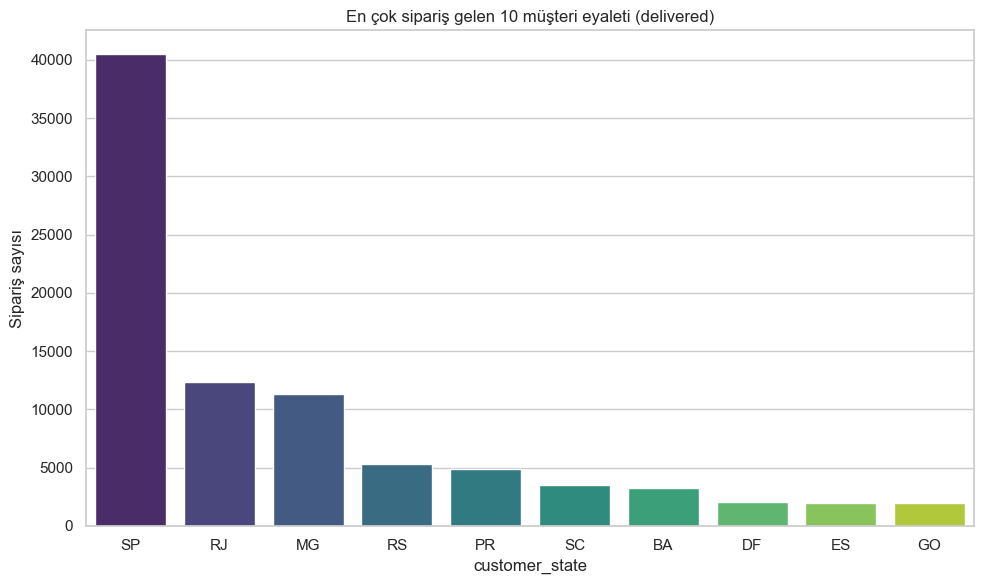

,items_sold,revenue
seller_state,,
SP,78604,9957056.91
MG,8603,1184427.54
PR,8487,1424161.25
RJ,4685,911918.67
SC,4000,717739.37
RS,2169,429749.09
DF,883,112892.78
BA,624,297146.93
GO,508,77089.48


In [27]:
# Müşteri eyaletine göre sipariş ve gelir (delivered)
state_metrics = (
    fact_delivered
    .groupby("customer_state")
    .agg(
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
        revenue=("total_item_value", "sum"),
    )
    .sort_values("orders", ascending=False)
)

display(state_metrics.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=state_metrics.head(10).reset_index(),
    x="customer_state",
    y="orders",
    hue="customer_state",
    palette="viridis",
    legend=False,
)
plt.title("En çok sipariş gelen 10 müşteri eyaleti (delivered)")
plt.xlabel("customer_state")
plt.ylabel("Sipariş sayısı")
plt.tight_layout()
plt.show()

# Satıcı eyaletine göre satılan item sayısı (delivered)
seller_state_metrics = (
    fact_delivered
    .groupby("seller_state")
    .agg(
        items_sold=("order_item_id", "count"),
        revenue=("total_item_value", "sum"),
    )
    .sort_values("items_sold", ascending=False)
)

display(seller_state_metrics.head(10))


## Teslimat süresi ve gecikme analizi

Gerçek teslimat süresi (purchase→delivered), tahmini süre (purchase→estimated) ve aradaki farkı inceleyeceğiz.

,count,mean,std,min,25%,50%,75%,max
delivery_days,110189.0,12.007342,9.451153,0.0,6.0,10.0,15.0,209.0
estimated_days,110197.0,23.439631,8.822024,2.0,18.0,23.0,28.0,155.0
delay_vs_estimate,110189.0,-11.432285,10.168323,-146.0,-17.0,-12.0,-7.0,189.0


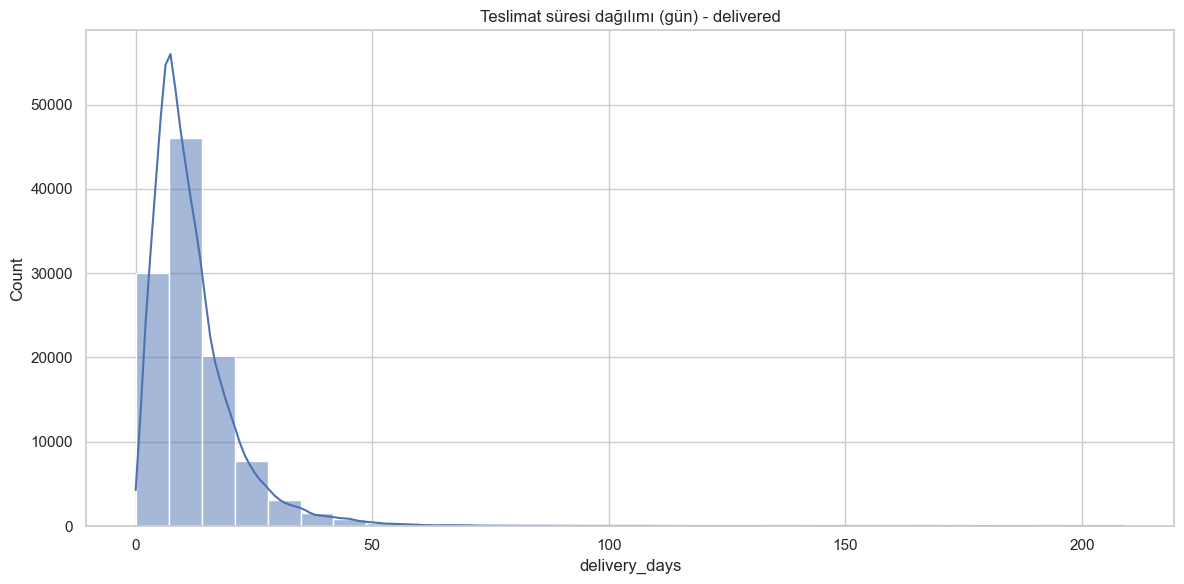

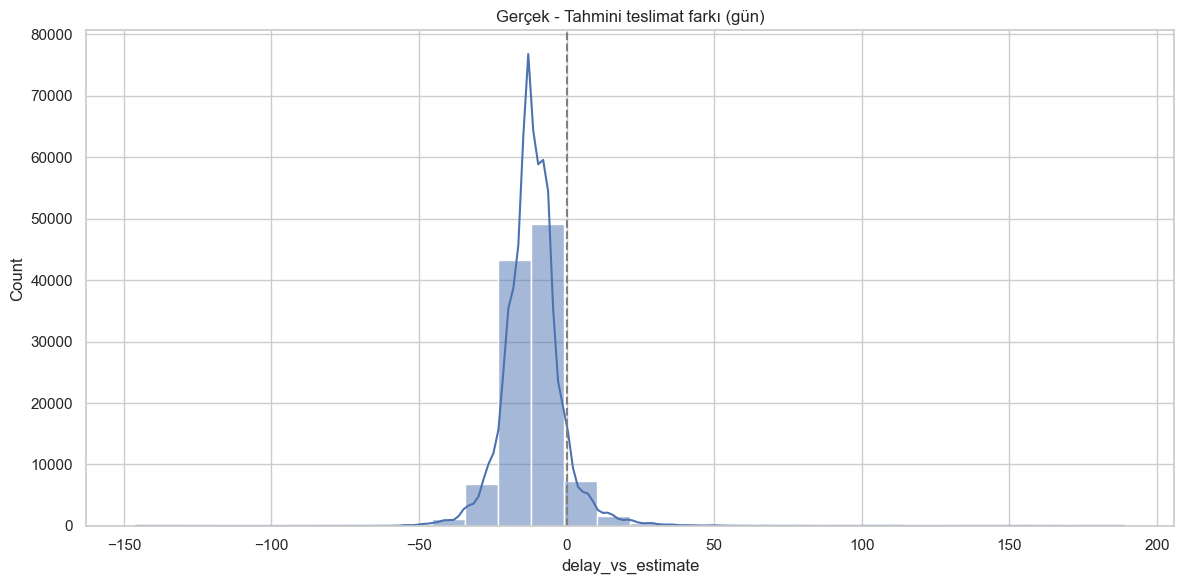

In [31]:
# Teslimat süreleri (delivered)
fact_delivered = fact_delivered.copy() 
fact_delivered["delivery_days"] = (
    fact_delivered["order_delivered_customer_date"]
    - fact_delivered["order_purchase_timestamp"]
).dt.days

fact_delivered["estimated_days"] = (
    fact_delivered["order_estimated_delivery_date"]
    - fact_delivered["order_purchase_timestamp"]
).dt.days

fact_delivered["delay_vs_estimate"] = fact_delivered["delivery_days"] - fact_delivered["estimated_days"]

# Özet istatistikler
display(fact_delivered[["delivery_days", "estimated_days", "delay_vs_estimate"]].describe().T)

sns.histplot(data=fact_delivered, x="delivery_days", bins=30, kde=True)
plt.title("Teslimat süresi dağılımı (gün) - delivered")
plt.xlabel("delivery_days")
plt.tight_layout()
plt.show()

sns.histplot(data=fact_delivered, x="delay_vs_estimate", bins=30, kde=True)
plt.title("Gerçek - Tahmini teslimat farkı (gün)")
plt.xlabel("delay_vs_estimate")
plt.axvline(0, color="grey", linestyle="--")
plt.tight_layout()
plt.show()


## Review score analizi

`review_score` dağılımını ve kategori bazında ortalama skorları inceleyeceğiz.

review_score
1.000000    11.007282
1.500000     0.008170
2.000000     3.128160
2.500000     0.033702
3.000000     8.254951
3.333333     0.001021
3.500000     0.025532
4.000000    19.389891
4.333333     0.001021
4.500000     0.055149
5.000000    58.095121
Name: count, dtype: float64

/var/folders/0n/l1l_2y613jb9_l5sgq8gdfm00000gn/T/ipykernel_89833/2841097159.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=review_pct.index.astype(int), y=review_pct.values, palette="RdYlGn")


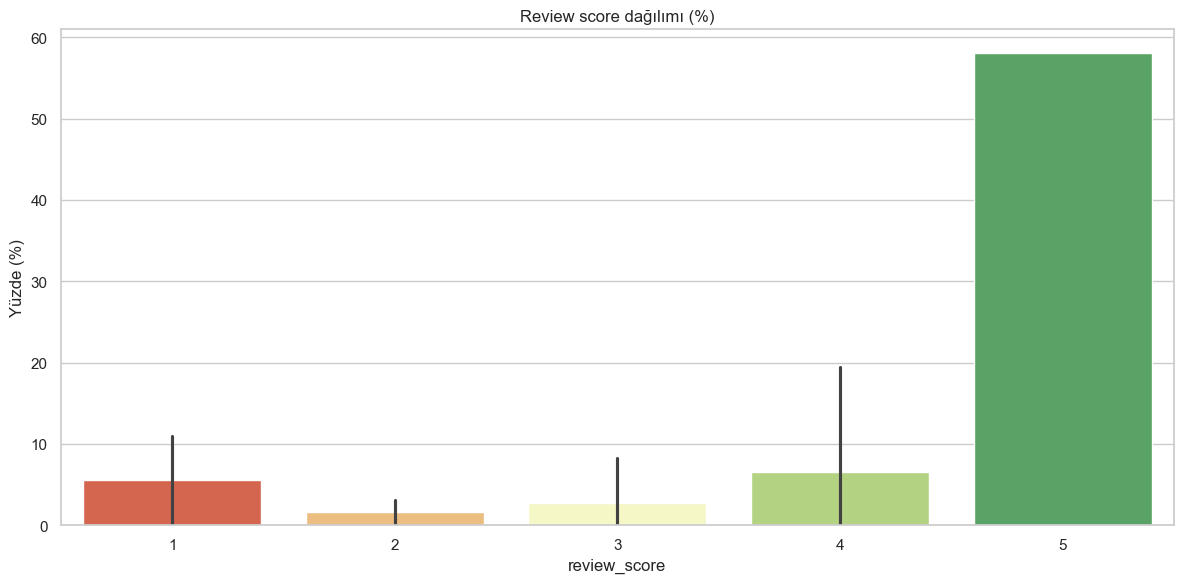

,avg_review,review_count
product_category_name_english,,
office_furniture,3.513301,1654
fixed_telephony,3.757937,252
fashion_male_clothing,3.758065,124
audio,3.836592,358
home_confort,3.854801,427
bed_bath_table,3.923968,10831
furniture_living_room,3.934694,490
furniture_decor,3.953775,8080
home_construction,3.957770,592


,avg_review,review_count
product_category_name_english,,
home_appliances,4.222148,751
small_appliances,4.225115,653
stationery,4.245818,2451
furniture_bedroom,4.252427,103
food,4.262834,487
fashion_shoes,4.290514,253
luggage_accessories,4.352283,1073
food_drink,4.366171,269
books_technical,4.389313,262


In [32]:
# Review score dağılımı (order-level)
review_dist = (
    fact_orders
    .drop_duplicates("order_id")["review_score"]
    .dropna()
    .value_counts()
    .sort_index()
)
review_pct = review_dist / review_dist.sum() * 100

display(review_pct)

sns.barplot(x=review_pct.index.astype(int), y=review_pct.values, hue=review_pct.index.astype(int), palette="RdYlGn", legend=False)
plt.title("Review score dağılımı (%)")
plt.xlabel("review_score")
plt.ylabel("Yüzde (%)")
plt.tight_layout()
plt.show()

# Kategori bazında ortalama review (yeterli örnek olan kategoriler)
cat_review = (
    fact_delivered
    .groupby("product_category_name_english")
    .agg(avg_review=("review_score", "mean"), review_count=("review_score", "count"))
    .query("review_count >= 100")
    .sort_values("avg_review")
)

display(cat_review.head(10))
display(cat_review.tail(10))


## Ödeme yöntemi ve taksit analizi

`payment_type` ve `payment_installments` üzerinden ödeme davranışlarını inceliyoruz.

,payment_type,orders,total_value,avg_installments
1,credit_card,76505,12542084.19,3.507155
0,boleto,19784,2869361.27,1.000000
3,voucher,3866,379436.87,1.000000
2,debit_card,1528,217989.79,1.000000


/var/folders/0n/l1l_2y613jb9_l5sgq8gdfm00000gn/T/ipykernel_89833/2763481498.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pay_metrics, x="payment_type", y="orders", palette="mako")


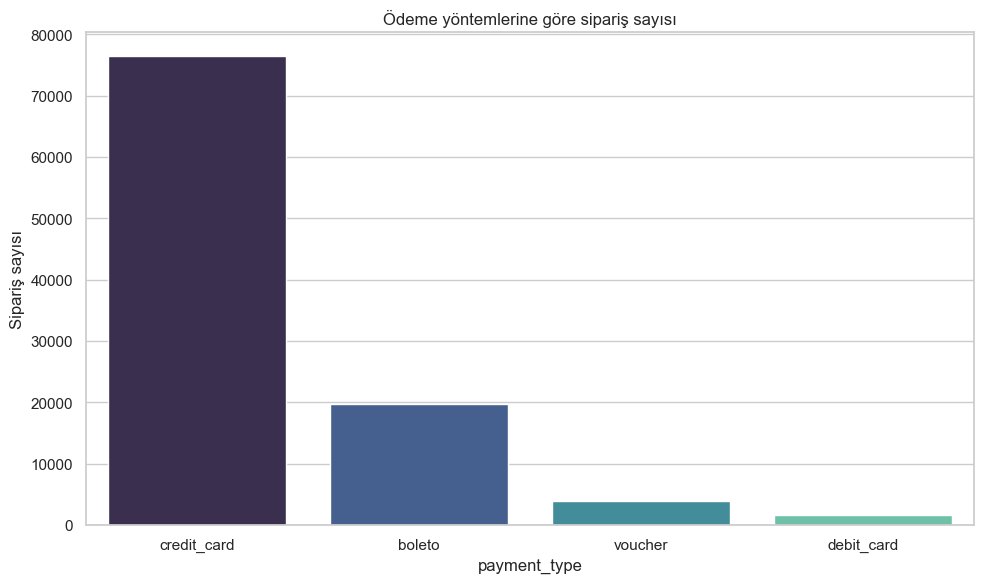

payment_installments
0      0.001925
1     50.579017
2     11.949020
3     10.069983
4      6.832687
5      5.043174
6      3.773476
7      1.565222
8      4.108468
9      0.619928
10     5.128847
11     0.022140
12     0.128029
13     0.015402
14     0.014439
Name: proportion, dtype: float64

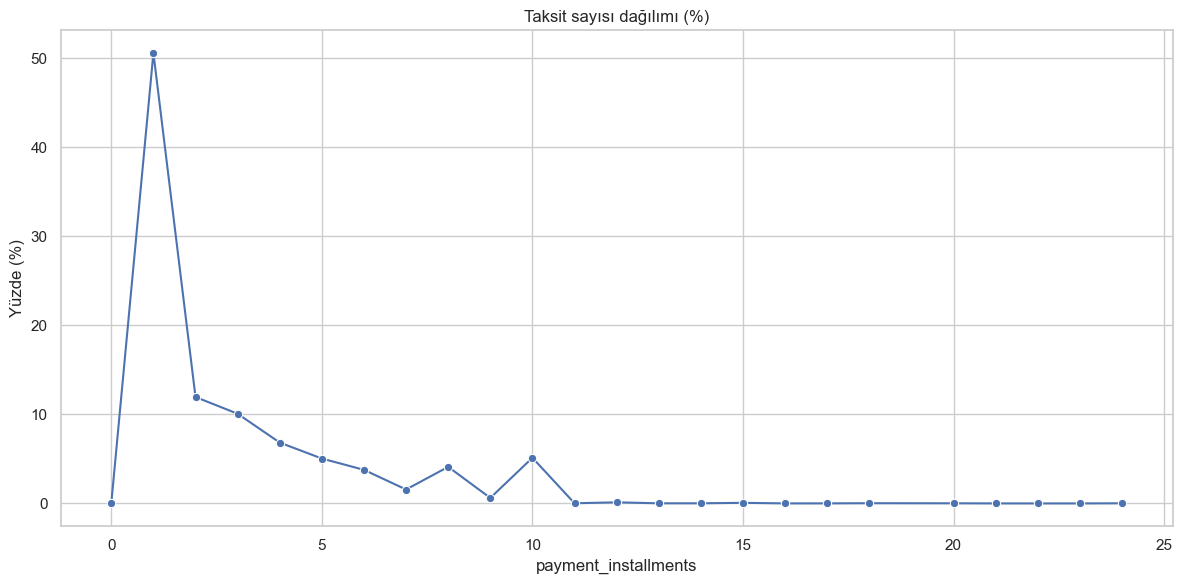

In [34]:
order_payments = order_payments[order_payments["payment_type"] != "not_defined"]
pay_metrics = (
    order_payments
    .groupby("payment_type", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        total_value=("payment_value", "sum"),
        avg_installments=("payment_installments", "mean"),
    )
    .sort_values("orders", ascending=False)
)

display(pay_metrics)

plt.figure(figsize=(10, 6))
sns.barplot(data=pay_metrics, x="payment_type", y="orders", hue="payment_type", palette="mako", legend=False)
plt.title("Ödeme yöntemlerine göre sipariş sayısı")
plt.xlabel("payment_type")
plt.ylabel("Sipariş sayısı")
plt.tight_layout()
plt.show()

installment_dist = order_payments["payment_installments"].value_counts(normalize=True).sort_index() * 100

display(installment_dist.head(15))

sns.lineplot(x=installment_dist.index, y=installment_dist.values, marker="o")
plt.title("Taksit sayısı dağılımı (%)")
plt.xlabel("payment_installments")
plt.ylabel("Yüzde (%)")
plt.tight_layout()
plt.show()


## Özet

Bu notebook'ta, `fact_orders` veri seti üzerinden EDA'nın temel ve kritik parçalarını tamamladık:

- Veri yapısı & eksik değer incelemesi
- Temel KPI'lar
- Aylık trend + MoM büyüme
- Kategori bazlı analiz
- Müşteri tekrar satın alma ve segmentasyon
- Coğrafi kırılım
- Teslimat süresi / gecikme
- Review skorları
- Ödeme yöntemleri ve taksit davranışı

Sonraki adım olarak `03_trend_analysis` ve `04_business_insights` notebook'larında bulguları daha derinleştirip aksiyon önerilerine çevirebiliriz.